# PROJET DE PREDICTION DU RISQUE D'ABANDONS SCOLAIRE

## 1. Objectif

Construire un modèle de Machine Learning capable de prédire si un étudiant risque d’abandonner
ses études, à partir de données académiques et comportementales.

## 2. Dataset

**Variable** - Description \
**age** - Âge de l’étudiant \
**gender** - Sexe (Male/Female) \
**average_grade** - Moyenne générale (/20) \
**absenteeism_rate** - Taux d’absence (0 à 0.5) \
**internet_access** - Accès à Internet (Yes/No) \
**study_time_hours** - Temps d’étude journalier \
**extra_activities** - Activités extrascolaires \
**dropout_risk Variable** - cible (0 = Non, 1 = Risque d’abandon) 

## 3. Logique du dataset

La variable cible dropout_risk est basée sur :
- Faible moyenne (< 10)
- Fort absentéisme (> 30%)
- Faible temps d’étude (< 1h) \
Si au moins 2 conditions sont vérifiées : Risque = 1

## IMPORTATION DES LIBRARIES

In [38]:
import warnings
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

# import the metrics class
from sklearn import metrics
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score,precision_score, recall_score,f1_score,classification_report
warnings.filterwarnings('ignore')

## CHARGEMENT DU JEU DE DONNÉES

In [39]:
df = pd.read_csv("student_dropout_dataset.csv")
df

,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk
0,21,Male,16.27,0.35,Yes,4.1,No,0
1,18,Female,12.30,0.38,No,0.2,No,1
2,22,Male,8.10,0.04,No,3.4,No,0
3,19,Male,13.84,0.25,No,4.8,Yes,0
4,21,Female,14.62,0.47,Yes,0.6,Yes,1
...,...,...,...,...,...,...,...,...
295,15,Female,17.58,0.04,Yes,3.6,No,0
296,19,Male,14.24,0.00,Yes,0.1,Yes,0
297,20,Male,7.59,0.48,No,1.7,No,1
298,17,Female,14.57,0.00,Yes,4.1,Yes,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               300 non-null    int64  
 1   gender            300 non-null    object 
 2   average_grade     300 non-null    float64
 3   absenteeism_rate  300 non-null    float64
 4   internet_access   300 non-null    object 
 5   study_time_hours  300 non-null    float64
 6   extra_activities  300 non-null    object 
 7   dropout_risk      300 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 18.9+ KB


In [41]:
df.describe()

,age,average_grade,absenteeism_rate,study_time_hours,dropout_risk
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,19.326667,11.600067,0.257633,2.516000,0.243333
std,2.873001,3.705599,0.138460,1.341321,0.429812
min,15.000000,5.030000,0.000000,0.000000,0.000000
25%,17.000000,8.440000,0.147500,1.400000,0.000000
50%,19.000000,11.755000,0.260000,2.600000,0.000000
75%,22.000000,14.640000,0.380000,3.525000,0.000000
max,24.000000,17.960000,0.500000,5.000000,1.000000


In [42]:
df.dtypes

age                   int64
gender               object
average_grade       float64
absenteeism_rate    float64
internet_access      object
study_time_hours    float64
extra_activities     object
dropout_risk          int64
dtype: object

## Prétraitement des données (Data Cleaning)

In [44]:
# Gestion des valeurs manques

df.isnull().sum()

age                 0
gender              0
average_grade       0
absenteeism_rate    0
internet_access     0
study_time_hours    0
extra_activities    0
dropout_risk        0
dtype: int64

In [45]:
# Presence de valuer negatif dans la colone age
nega = (df["age"] < 0).sum()
nega

np.int64(0)

In [46]:
# Doublon

db = df.duplicated().sum()
db

np.int64(0)

In [47]:
df

,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk
0,21,Male,16.27,0.35,Yes,4.1,No,0
1,18,Female,12.30,0.38,No,0.2,No,1
2,22,Male,8.10,0.04,No,3.4,No,0
3,19,Male,13.84,0.25,No,4.8,Yes,0
4,21,Female,14.62,0.47,Yes,0.6,Yes,1
...,...,...,...,...,...,...,...,...
295,15,Female,17.58,0.04,Yes,3.6,No,0
296,19,Male,14.24,0.00,Yes,0.1,Yes,0
297,20,Male,7.59,0.48,No,1.7,No,1
298,17,Female,14.57,0.00,Yes,4.1,Yes,0


## Analyse exploratoire

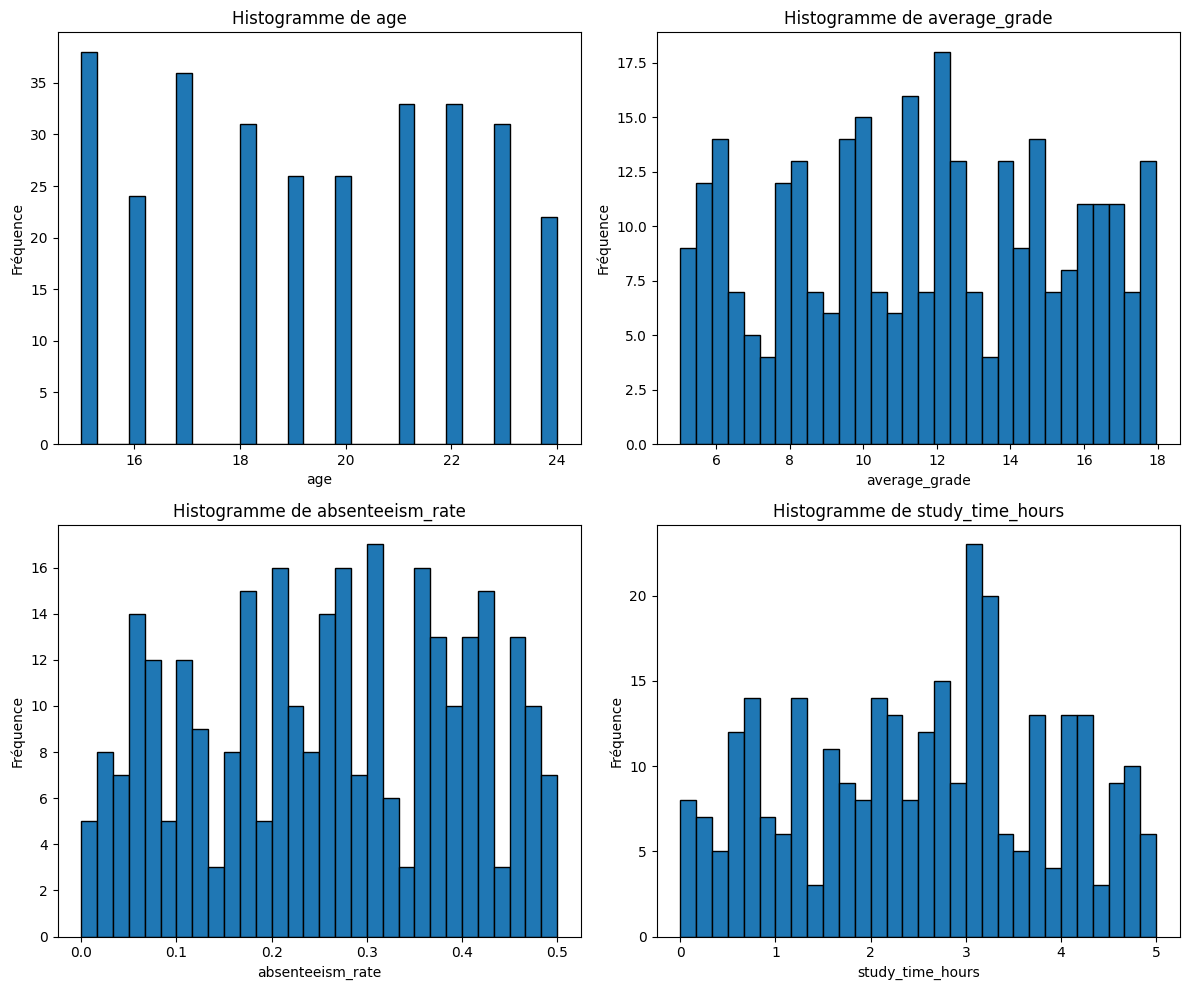

In [48]:
# HISTOGRAMME 

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
variable = ["age","average_grade","absenteeism_rate","study_time_hours"]
for i, var in enumerate(variable):
    axes[i].hist(df[var], bins=30, edgecolor='black')
    axes[i].set_title(f"Histogramme de {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

Les variables absenteeism_rate et study_time_hours sont asymétriques (majorité d’absents faibles et de temps d’étude modérés). 
Les conditions de risque sont relativement rares, ce qui peut créer un déséquilibre de classes dans la cible dropout_risk.

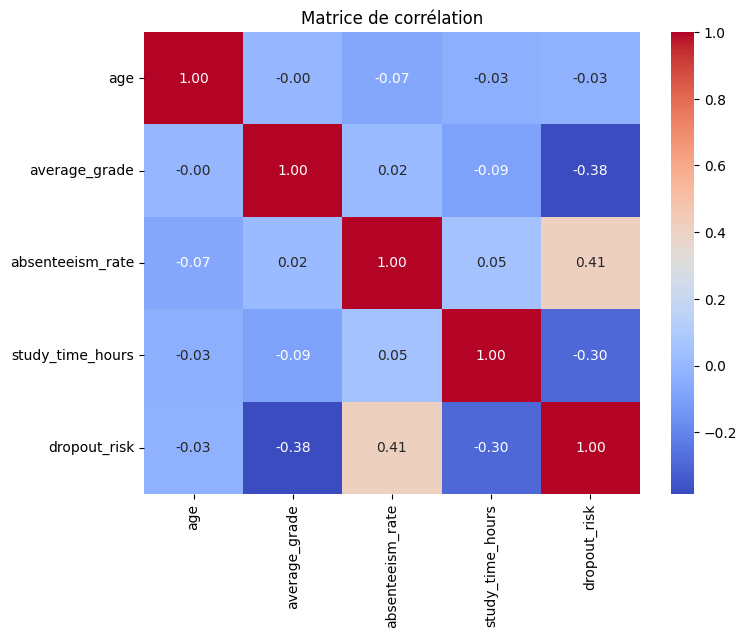

In [49]:
# Matrice de correlation
corr_matrice = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrice, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show() # Affiche la heatmap [10]

les variables qui sont correlé avec la variable cible dropout_risk sont : average_grade, absenteeinsm_rate, study_time_hour
- absenteeinsm_rate : première variable la plus correlé avec la variable cible 
- average_grade : deuxieme variable la plus correlé avec la variable cible 
- study_time_hour : troisieme variable la plus correlé avec la variable cible 

la variable age n'a aucun impact sur la variable cible dropout_risk .

## Feature Engineering

In [50]:
# Ratio présence/absence
df['presence_ratio'] = 1 - df['absenteeism_rate']

# Score global (pondération fixe, arbitraire)
df['global_score'] = (df['average_grade'] * 0.5 + 
                      df['study_time_hours'] * 0.3 - 
                      df['absenteeism_rate'] * 0.2)

In [51]:
df

,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk,presence_ratio,global_score
0,21,Male,16.27,0.35,Yes,4.1,No,0,0.65,9.295
1,18,Female,12.30,0.38,No,0.2,No,1,0.62,6.134
2,22,Male,8.10,0.04,No,3.4,No,0,0.96,5.062
3,19,Male,13.84,0.25,No,4.8,Yes,0,0.75,8.310
4,21,Female,14.62,0.47,Yes,0.6,Yes,1,0.53,7.396
...,...,...,...,...,...,...,...,...,...,...
295,15,Female,17.58,0.04,Yes,3.6,No,0,0.96,9.862
296,19,Male,14.24,0.00,Yes,0.1,Yes,0,1.00,7.150
297,20,Male,7.59,0.48,No,1.7,No,1,0.52,4.209
298,17,Female,14.57,0.00,Yes,4.1,Yes,0,1.00,8.515


In [52]:
X = df.drop('dropout_risk', axis=1)
y = df['dropout_risk']

In [53]:
col_num = ["age","average_grade","absenteeism_rate","study_time_hours","presence_ratio","global_score"]
col_categorial = ["gender","internet_access","extra_activities"]

In [54]:
ct = ColumnTransformer(
    [("numerique", StandardScaler(),col_num),
     ("categorial", OneHotEncoder(drop="first"),col_categorial)])

## SPLIT DU DATASET

In [55]:
# Split (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [56]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (240, 9), Test: (60, 9)


## MODELISATION

In [57]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

In [58]:
results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ("prep", ct),
        ("clf", model)
    ])
    
    # Validation croisée
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="f1")
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results[name] = {
        "CV F1 moyen": cv_scores.mean(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred)
    }
    
    print(f"\n{'='*50}")
    print(f"Modèle : {name}")
    print(f"{'='*50}")
    print(f"Validation croisée F1 (moy ± std) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"\nClassification Report sur test :")
    print(classification_report(y_test, y_pred))
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))



Modèle : Logistic Regression
Validation croisée F1 (moy ± std) : 0.757 ± 0.050

Classification Report sur test :
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        45
           1       0.79      0.73      0.76        15

    accuracy                           0.88        60
   macro avg       0.85      0.83      0.84        60
weighted avg       0.88      0.88      0.88        60

Matrice de confusion :
[[42  3]
 [ 4 11]]

Modèle : Random Forest
Validation croisée F1 (moy ± std) : 0.966 ± 0.017

Classification Report sur test :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        15

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Matrice de confusion :
[[45  0]
 [ 0 15]]

Modèle : SVM
Validation croisée F1 (moy

## OPTIMISATION

In [59]:
param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [5, 10, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4]
}

rf_base = RandomForestClassifier(random_state=42)
pipeline_rf = Pipeline([("prep", ct), ("clf", rf_base)])

grid_search = GridSearchCV(
    pipeline_rf, param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score F1 (validation) : {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Meilleurs paramètres : {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 100}
Meilleur score F1 (validation) : 0.991


In [60]:
# Évaluation du modèle optimisé
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"F1 score sur test : {f1_score(y_test, y_pred_best):.3f}")
print(f"Accuracy sur test : {accuracy_score(y_test, y_pred_best):.3f}")

F1 score sur test : 1.000
Accuracy sur test : 1.000


In [61]:
# SÉLECTION DES VARIABLES IMPORTANTES 
best_rf = best_model.named_steps["clf"]
feature_names = (col_num + 
                 list(best_model.named_steps["prep"].named_transformers_["categorial"].get_feature_names_out(col_categorial)))

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 5 des variables les plus importantes :")
print(importance_df.head(5))


Top 5 des variables les plus importantes :
            feature  importance
3  study_time_hours    0.268012
1     average_grade    0.214385
4    presence_ratio    0.178301
2  absenteeism_rate    0.165862
5      global_score    0.159545


## SAUVEGARDE DU MODEL

In [26]:
# Sauvegarder le modèle
with open('abandon_predict.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [ ]:
df.info()   # 300 entrées, pas de valeurs manquantes
df.duplicated().sum()  # 0 doublon
(df["age"] < 0).sum()  # 0 valeur négative